In [77]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [78]:
# loading the datasets 
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')


### 1. Setup and Initial Exploration 

In [79]:
train

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False


In [80]:
# shape
print(train.shape)
print(test.shape)


(8693, 14)
(4277, 13)


In [81]:
print(train.dtypes)
print("-----------------------")

print(test.dtypes)


PassengerId      object
HomePlanet       object
CryoSleep        object
Cabin            object
Destination      object
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name             object
Transported        bool
dtype: object
-----------------------
PassengerId      object
HomePlanet       object
CryoSleep        object
Cabin            object
Destination      object
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name             object
dtype: object


In [82]:
print(train.columns)
print(test.columns)


Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Transported'],
      dtype='object')
Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name'],
      dtype='object')


### 2. Quick EDA 

In [83]:
# checking null cols
print(test.isnull().sum())
print("-------------------")
print(train.isnull().sum())

PassengerId       0
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64
-------------------
PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64


Text(0.5, 1.0, 'heatmap')

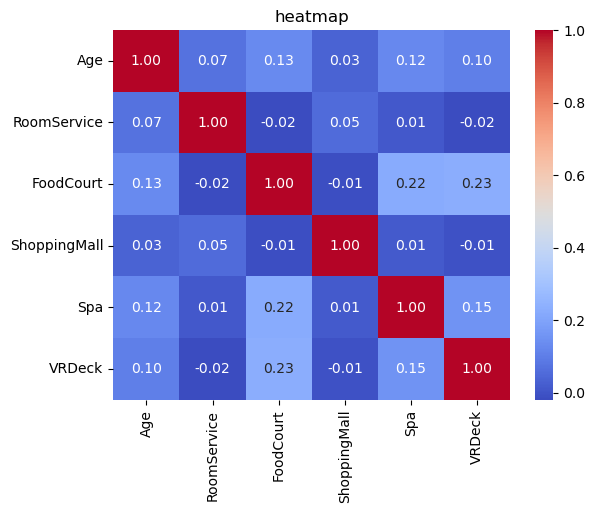

In [84]:
# heatmap
numerical_cols = train.select_dtypes(include=['int64','float64'])
corr = numerical_cols.corr()
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt=".2f")
plt.title("heatmap")

Transported
True     4378
False    4315
Name: count, dtype: int64
Transported
True     0.503624
False    0.496376
Name: proportion, dtype: float64


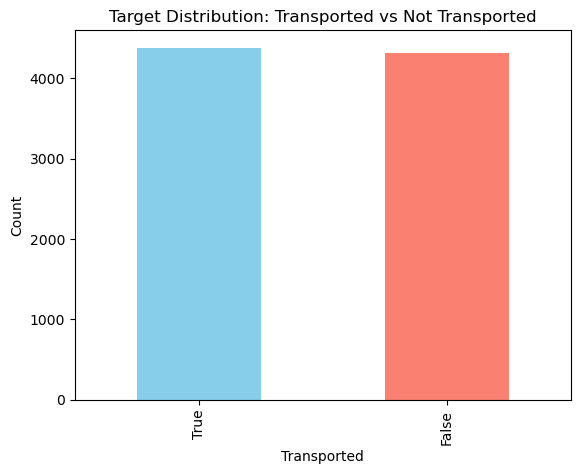

In [85]:

# Check the unique values in the target column
print(train["Transported"].value_counts())

# Check relative proportionss
print(train["Transported"].value_counts(normalize=True))

train["Transported"].value_counts().plot(kind="bar", color=["skyblue", "salmon"])
plt.title("Target Distribution: Transported vs Not Transported")
plt.xlabel("Transported")
plt.ylabel("Count")
plt.show()


In [86]:
# numerical  caterogical features count 
train.dtypes

PassengerId      object
HomePlanet       object
CryoSleep        object
Cabin            object
Destination      object
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name             object
Transported        bool
dtype: object

In [87]:
train.PassengerId

0       0001_01
1       0002_01
2       0003_01
3       0003_02
4       0004_01
         ...   
8688    9276_01
8689    9278_01
8690    9279_01
8691    9280_01
8692    9280_02
Name: PassengerId, Length: 8693, dtype: object

In [91]:
train[['Group','GroupMember']] = train['PassengerId'].str.split('_',expand=True)
train['Group'] = train['Group'].astype(int)
train['GroupMember'] = train['GroupMember'].astype(int)




In [92]:
group_transport_rate = train.groupby('Group')['Transported'].mean()


In [93]:
group_transport_rate

Group
1       0.000000
2       1.000000
3       0.000000
4       1.000000
5       1.000000
          ...   
9275    0.666667
9276    0.000000
9278    0.000000
9279    1.000000
9280    0.500000
Name: Transported, Length: 6217, dtype: float64

In [94]:
pure_groups = (group_transport_rate == 0) | (group_transport_rate == 1)
pure_ratio = pure_groups.mean()
print(f"{pure_ratio:.2%} of groups have all members transported or all not transported.")


87.18% of groups have all members transported or all not transported.
